# Exploracion inicial de datos

## Recomendacion local de citas academicas

Este notebook presenta una exploracion breve del dataset utilizado para recomendar citas en textos academicos. El objetivo es comprender su contenido, comprobar su calidad y obtener conclusiones utiles antes de construir el modelo.

Cada registro contiene un fragmento de un articulo academico en el que se oculto una referencia. A partir de ese fragmento, el sistema debe identificar cual de los articulos disponibles corresponde a la cita original. Los datos pertenecen al conjunto **ACL-200** y fueron obtenidos del repositorio [Local Citation Recommendation](https://github.com/nianlonggu/Local-Citation-Recommendation).

Los archivos originales se encuentran en `data/raw/`, estan gestionados por DVC y no se modifican durante este analisis.

In [1]:
!pip install matplotlib pandas seaborn scikit-learn

## 1. Preparacion y carga

Se cargan los cinco archivos del dataset y se preparan tablas para relacionar contextos, articulos y particiones.

In [2]:
import json
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "data" / "raw.dvc").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FILES = ["contexts.json", "papers.json", "train.json", "val.json", "test.json"]

missing = [name for name in FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"Faltan archivos: {missing}. Ejecuta `uv run dvc pull`.")


def load_json(name: str):
    with (DATA_DIR / name).open(encoding="utf-8") as file:
        return json.load(file)


contexts = load_json("contexts.json")
papers = load_json("papers.json")
splits = {name: load_json(f"{name}.json") for name in ("train", "val", "test")}

contexts_df = pd.DataFrame.from_dict(contexts, orient="index").reset_index(names="dictionary_key")
papers_df = pd.DataFrame.from_dict(papers, orient="index").reset_index(names="paper_id")
split_df = pd.concat(
    [pd.DataFrame(rows).assign(split=name) for name, rows in splits.items()],
    ignore_index=True,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

print(f"Python: {platform.python_version()}")
print(f"Datos: {DATA_DIR}")

Python: 3.14.6
Datos: /Users/josezambrana/Estudio/Maestria Inteligencia Artificial/16 Desarrollo de proyectos/microproyecto-local-citation/data/raw


## 2. Descripcion del dataset

El dataset contiene tres tipos de informacion:

| Componente | Archivos | Contenido |
|---|---|---|
| Contextos | `contexts.json` | Texto local, articulo citante y articulo citado |
| Articulos | `papers.json` | Titulo y resumen de los articulos candidatos |
| Particiones | `train.json`, `val.json`, `test.json` | Consultas y articulos positivos |

La relacion principal es: **contexto con `TARGETCIT` -> articulo citado (`refid`) -> titulo y resumen en `papers.json`**.

In [3]:
inventory = pd.DataFrame(
    {
        "archivo": FILES,
        "registros": [len(contexts), len(papers), *(len(splits[name]) for name in ("train", "val", "test"))],
        "tamano_mb": [(DATA_DIR / name).stat().st_size / 1024**2 for name in FILES],
    }
)
display(inventory.style.format({"registros": "{:,}", "tamano_mb": "{:.2f}"}))

,archivo,registros,tamano_mb
0,contexts.json,"63,768",37.62
1,papers.json,"19,776",23.39
2,train.json,"30,390",2.00
3,val.json,"9,381",0.62
4,test.json,"9,585",0.63


### Ejemplo de una observacion

In [4]:
example = split_df.iloc[0]
context = contexts[example["context_id"]]
citing_paper = papers[context["citing_id"]]
cited_paper = papers[context["refid"]]

display(
    Markdown(
        f"**Contexto:** {context['masked_text']}\n\n"
        f"**Articulo citante:** {citing_paper['title']}\n\n"
        f"**Articulo citado:** {cited_paper['title']}\n\n"
        f"**ID positivo:** `{example['positive_ids'][0]}`"
    )
)

**Contexto:** e and target languages are annotated with a coarse parts-of-speech tagset which is shared across languages. Such tagsets are commonly used in multilingual parsing (OTHERCIT; McOTHERCIT; Søgaard, 2011; TARGETCIT . The key feature of our model is a two-tier approach that separates the selection of dependents from their ordering: 1. Selection Component: Determines the dependent tags given the parent tag. 2. Ord

**Articulo citante:** Selective Sharing for Multilingual Dependency Parsing

**Articulo citado:** Using Universal Linguistic Knowledge to Guide Grammar Induction

**ID positivo:** `D10-1120`

## 3. Tamano y calidad de los datos

Se comprueba si las relaciones principales son validas, si faltan textos y si la etiqueta positiva coincide con el articulo realmente citado.

In [5]:
context_lookup = contexts_df.set_index("context_id")
split_df["refid"] = split_df["context_id"].map(context_lookup["refid"])
split_df["citing_id"] = split_df["context_id"].map(context_lookup["citing_id"])
split_df["positive_id"] = split_df["positive_ids"].str[0]

quality = pd.DataFrame(
    {
        "comprobacion": [
            "Contextos referenciados inexistentes",
            "Articulos citados inexistentes",
            "Titulos vacios",
            "Resumenes vacios",
            "Contextos sin TARGETCIT",
            "Contextos con mas de un TARGETCIT",
            "Consultas sin un unico positivo",
            "Positive ID diferente de refid",
            "Textos de contexto duplicados",
        ],
        "cantidad": [
            split_df["context_id"].isna().sum() + (~split_df["context_id"].isin(contexts)).sum(),
            (~split_df["refid"].isin(papers)).sum(),
            papers_df["title"].str.strip().eq("").sum(),
            papers_df["abstract"].str.strip().eq("").sum(),
            contexts_df["masked_text"].str.count(r"\bTARGETCIT\b").eq(0).sum(),
            contexts_df["masked_text"].str.count(r"\bTARGETCIT\b").gt(1).sum(),
            split_df["positive_ids"].str.len().ne(1).sum(),
            split_df["positive_id"].ne(split_df["refid"]).sum(),
            contexts_df["masked_text"].duplicated().sum(),
        ],
    }
)
display(quality.style.format({"cantidad": "{:,}"}))

,comprobacion,cantidad
0,Contextos referenciados inexistentes,0
1,Articulos citados inexistentes,0
2,Titulos vacios,0
3,Resumenes vacios,0
4,Contextos sin TARGETCIT,0
5,Contextos con mas de un TARGETCIT,0
6,Consultas sin un unico positivo,0
7,Positive ID diferente de refid,0
8,Textos de contexto duplicados,"1,705"


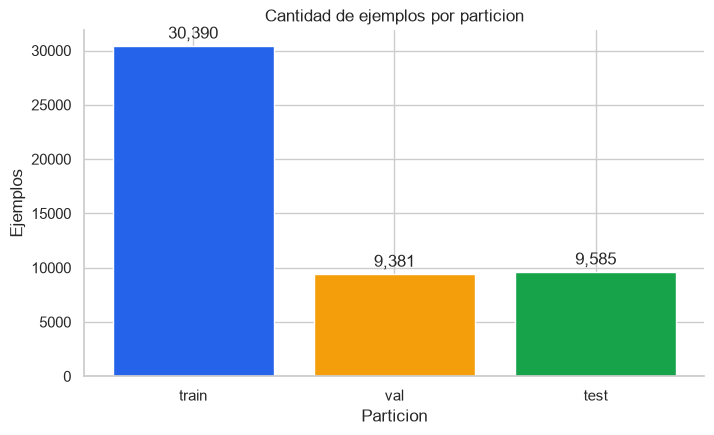

In [6]:
split_order = ["train", "val", "test"]
split_sizes = split_df["split"].value_counts().reindex(split_order)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(split_sizes.index, split_sizes.values, color=["#2563eb", "#f59e0b", "#16a34a"])
ax.bar_label(bars, labels=[f"{value:,}" for value in split_sizes.values], padding=3)
ax.set(title="Cantidad de ejemplos por particion", xlabel="Particion", ylabel="Ejemplos")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 4. Caracteristicas de los textos

La longitud de los textos permite anticipar si sera necesario truncar la entrada de modelos como SciBERT. Los conteos se realizan por palabras para facilitar su interpretacion.

In [7]:
contexts_df["context_words"] = contexts_df["masked_text"].str.split().str.len()
contexts_df["othercit_count"] = contexts_df["masked_text"].str.count(r"\bOTHERCIT\b")
papers_df["title_words"] = papers_df["title"].str.split().str.len()
papers_df["abstract_words"] = papers_df["abstract"].str.split().str.len()

text_summary = pd.DataFrame(
    {
        "texto": ["Contexto", "Titulo", "Resumen"],
        "mediana_palabras": [
            contexts_df["context_words"].median(),
            papers_df["title_words"].median(),
            papers_df["abstract_words"].median(),
        ],
        "percentil_95": [
            contexts_df["context_words"].quantile(0.95),
            papers_df["title_words"].quantile(0.95),
            papers_df["abstract_words"].quantile(0.95),
        ],
        "maximo": [
            contexts_df["context_words"].max(),
            papers_df["title_words"].max(),
            papers_df["abstract_words"].max(),
        ],
    }
)
display(text_summary.style.format({"mediana_palabras": "{:.0f}", "percentil_95": "{:.0f}", "maximo": "{:.0f}"}))

,texto,mediana_palabras,percentil_95,maximo
0,Contexto,63,72,153
1,Titulo,8,15,110
2,Resumen,106,465,13961


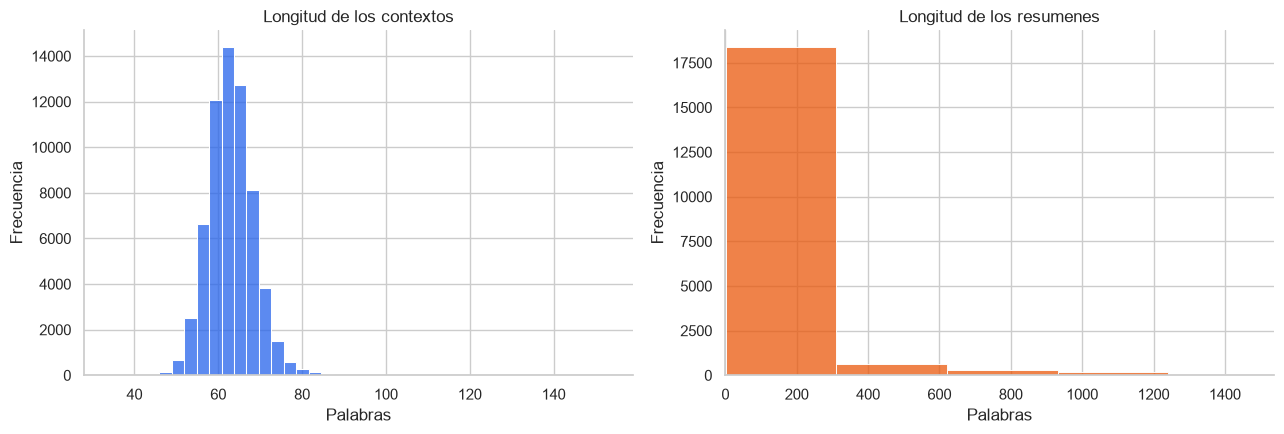

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(contexts_df["context_words"], bins=40, color="#2563eb", ax=axes[0])
sns.histplot(papers_df["abstract_words"], bins=45, color="#ea580c", ax=axes[1])

axes[0].set(title="Longitud de los contextos", xlabel="Palabras", ylabel="Frecuencia")
axes[1].set(
    title="Longitud de los resumenes",
    xlabel="Palabras",
    ylabel="Frecuencia",
    xlim=(0, papers_df["abstract_words"].quantile(0.99)),
)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Terminos caracteristicos de los contextos

Se eliminan los marcadores `TARGETCIT` y `OTHERCIT`, las palabras vacias del ingles y los signos de puntuacion. Luego se cuentan unigramas y bigramas para observar el vocabulario dominante del corpus.

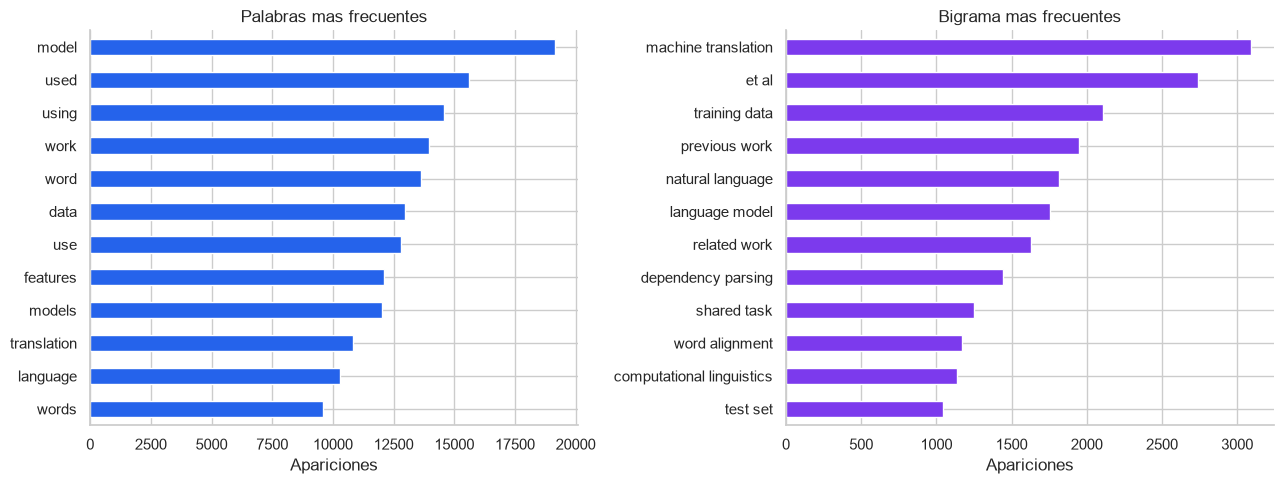

In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np

clean_contexts = (
    contexts_df["masked_text"]
    .str.replace("TARGETCIT", " ", regex=False)
    .str.replace("OTHERCIT", " ", regex=False)
)

term_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z-]+\b",
    ngram_range=(1, 2),
    min_df=20,
)
term_matrix = term_vectorizer.fit_transform(clean_contexts)
frequencies = np.asarray(term_matrix.sum(axis=0)).ravel()
terms = np.asarray(term_vectorizer.get_feature_names_out())
word_counts = pd.Series(frequencies[[" " not in term for term in terms]], index=terms[[" " not in term for term in terms]])
bigram_counts = pd.Series(frequencies[[" " in term for term in terms]], index=terms[[" " in term for term in terms]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
word_counts.nlargest(12).sort_values().plot.barh(ax=axes[0], color="#2563eb")
bigram_counts.nlargest(12).sort_values().plot.barh(ax=axes[1], color="#7c3aed")
axes[0].set(title="Palabras mas frecuentes", xlabel="Apariciones", ylabel="")
axes[1].set(title="Bigrama mas frecuentes", xlabel="Apariciones", ylabel="")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Similitud entre el contexto y los articulos

Para comprobar si el texto contiene una señal útil para recuperar la cita, se compara la similitud TF-IDF del contexto con:

- El artículo citado realmente (positivo).
- Un artículo seleccionado al azar (negativo).

Si los positivos presentan valores mayores, existe una señal léxica aprovechable por una línea base como BM25 o TF-IDF.

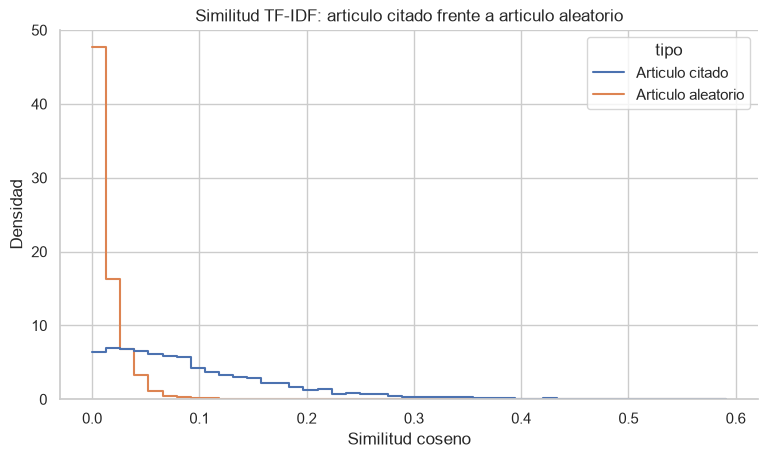

,mean,median,std
tipo,,,
Articulo aleatorio,0.014,0.009,0.016
Articulo citado,0.097,0.078,0.081


El articulo citado tiene mayor similitud que el aleatorio en 90.1% de la muestra.


In [10]:
SAMPLE_SIZE = 4_000
RANDOM_STATE = 42
sample = split_df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).copy()
paper_lookup = papers_df.set_index("paper_id")

sample["query"] = sample["context_id"].map(context_lookup["masked_text"])
sample["positive_text"] = sample["refid"].map(
    (paper_lookup["title"] + " " + paper_lookup["abstract"]).to_dict()
)

rng = np.random.default_rng(RANDOM_STATE)
paper_ids = papers_df["paper_id"].to_numpy()
negative_ids = rng.choice(paper_ids, size=SAMPLE_SIZE, replace=True)
same_as_positive = negative_ids == sample["refid"].to_numpy()
while same_as_positive.any():
    negative_ids[same_as_positive] = rng.choice(paper_ids, size=same_as_positive.sum(), replace=True)
    same_as_positive = negative_ids == sample["refid"].to_numpy()
sample["negative_text"] = [
    f"{paper_lookup.at[paper_id, 'title']} {paper_lookup.at[paper_id, 'abstract']}"
    for paper_id in negative_ids
]

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.95,
    max_features=20_000,
)
all_texts = pd.concat([sample["query"], sample["positive_text"], sample["negative_text"]], ignore_index=True)
matrix = tfidf.fit_transform(all_texts)
query_matrix = matrix[:SAMPLE_SIZE]
positive_matrix = matrix[SAMPLE_SIZE : 2 * SAMPLE_SIZE]
negative_matrix = matrix[2 * SAMPLE_SIZE :]

positive_similarity = np.asarray(query_matrix.multiply(positive_matrix).sum(axis=1)).ravel()
negative_similarity = np.asarray(query_matrix.multiply(negative_matrix).sum(axis=1)).ravel()

similarity_df = pd.DataFrame(
    {
        "similitud": np.concatenate([positive_similarity, negative_similarity]),
        "tipo": ["Articulo citado"] * SAMPLE_SIZE + ["Articulo aleatorio"] * SAMPLE_SIZE,
    }
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.histplot(
    data=similarity_df,
    x="similitud",
    hue="tipo",
    bins=45,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=ax,
)
ax.set(title="Similitud TF-IDF: articulo citado frente a articulo aleatorio", xlabel="Similitud coseno", ylabel="Densidad")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

similarity_summary = similarity_df.groupby("tipo")["similitud"].agg(["mean", "median", "std"])
display(similarity_summary.style.format("{:.3f}"))
print(f"El articulo citado tiene mayor similitud que el aleatorio en {(positive_similarity > negative_similarity).mean():.1%} de la muestra.")

## 5. Particiones y distribucion de citas

Ademas del tamano de cada particion, se comprueba que un mismo documento citante o par citante-citado no aparezca en conjuntos distintos. Esto evita que el modelo sea evaluado con documentos que ya observo durante el entrenamiento.

In [11]:
split_sets = {
    name: {
        "citing": set(group["citing_id"]),
        "pair": set(zip(group["citing_id"], group["refid"])),
    }
    for name, group in split_df.groupby("split")
}

overlap_rows = []
for left, right in [("train", "val"), ("train", "test"), ("val", "test")]:
    overlap_rows.append(
        {
            "comparacion": f"{left} vs {right}",
            "documentos_citantes_compartidos": len(split_sets[left]["citing"] & split_sets[right]["citing"]),
            "pares_compartidos": len(split_sets[left]["pair"] & split_sets[right]["pair"]),
        }
    )

display(pd.DataFrame(overlap_rows).style.format({
    "documentos_citantes_compartidos": "{:,}",
    "pares_compartidos": "{:,}",
}))

,comparacion,documentos_citantes_compartidos,pares_compartidos
0,train vs val,0,0
1,train vs test,0,0
2,val vs test,0,0


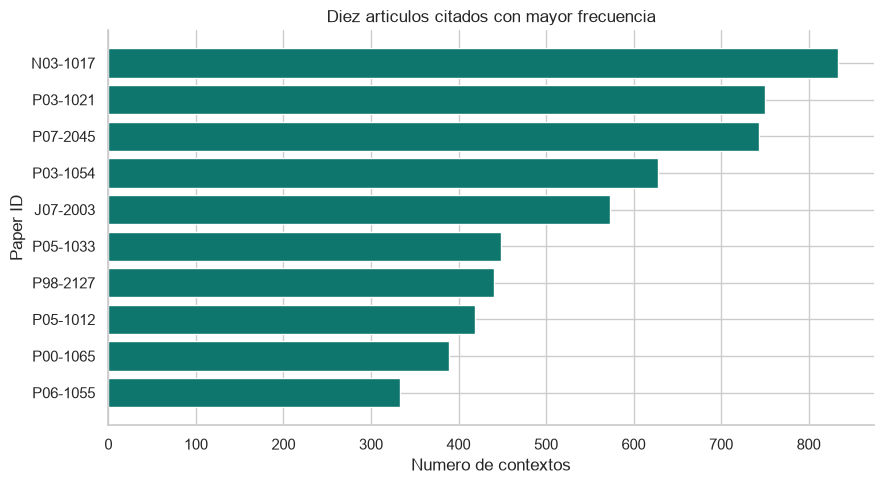

,paper_id,contextos,title
0,N03-1017,833,Statistical Phrase-Based Translation
1,P03-1021,750,Minimum Error Rate Training in Statistical Machine Translation
2,P07-2045,743,Moses: Open Source Toolkit for Statistical Machine Translation
3,P03-1054,628,Accurate Unlexicalized Parsing
4,J07-2003,573,Hierarchical Phrase-Based Translation
5,P05-1033,448,A Hierarchical Phrase-Based Model for Statistical Machine Translation
6,P98-2127,440,Automatic Retrieval and Clustering of Similar Words
7,P05-1012,419,Online Large-Margin Training of Dependency Parsers
8,P00-1065,389,Automatic Labeling of Semantic Roles
9,P06-1055,333,"Learning Accurate, Compact, and Interpretable Tree Annotation"


In [12]:
citation_counts = contexts_df["refid"].value_counts()
top_cited = (
    citation_counts.head(10)
    .rename("contextos")
    .to_frame()
    .join(papers_df.set_index("paper_id")[["title"]])
    .reset_index(names="paper_id")
)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = top_cited.sort_values("contextos")
ax.barh(plot_data["paper_id"], plot_data["contextos"], color="#0f766e")
ax.set(title="Diez articulos citados con mayor frecuencia", xlabel="Numero de contextos", ylabel="Paper ID")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

display(top_cited[["paper_id", "contextos", "title"]])

## 6. Conclusiones

In [13]:
unused_contexts = len(set(contexts) - set(split_df["context_id"]))
duplicate_contexts = int(contexts_df["masked_text"].duplicated().sum())
all_consistent = bool(split_df["positive_id"].eq(split_df["refid"]).all())
max_overlap = max(
    max(row["documentos_citantes_compartidos"], row["pares_compartidos"])
    for row in overlap_rows
)

conclusions = "\n".join(
    [
        f"- El corpus contiene **{len(contexts_df):,} contextos**, **{len(papers_df):,} articulos candidatos** y **{len(split_df):,} consultas**.",
        f"- Cada consulta tiene un unico positivo y su identificador coincide con `refid`: **{'si' if all_consistent else 'no'}**.",
        f"- No se encontraron fugas por documento citante o par citante-citado entre particiones: **{'si' if max_overlap == 0 else 'no'}**.",
        f"- Existen **{duplicate_contexts:,} textos de contexto duplicados** y **{unused_contexts:,} contextos fuera de train, validacion y test**; deben documentarse antes del modelado.",
        "- Las longitudes de los contextos y resumenes son variables, por lo que la tokenizacion y el truncamiento deben definirse y medirse al preparar SciBERT.",
        f"- En la muestra TF-IDF, el articulo citado supera al aleatorio en "        f"**{(positive_similarity > negative_similarity).mean():.1%} de los casos**, lo que confirma que existe señal léxica útil.",
        "- ACL-200 permite evaluar recomendacion de citas, pero **no contiene las nueve etiquetas de funcion de cita** planteadas en el proyecto.",
    ]
)
display(Markdown(conclusions))

- El corpus contiene **63,768 contextos**, **19,776 articulos candidatos** y **49,356 consultas**.
- Cada consulta tiene un unico positivo y su identificador coincide con `refid`: **si**.
- No se encontraron fugas por documento citante o par citante-citado entre particiones: **si**.
- Existen **1,705 textos de contexto duplicados** y **14,412 contextos fuera de train, validacion y test**; deben documentarse antes del modelado.
- Las longitudes de los contextos y resumenes son variables, por lo que la tokenizacion y el truncamiento deben definirse y medirse al preparar SciBERT.
- En la muestra TF-IDF, el articulo citado supera al aleatorio en **90.1% de los casos**, lo que confirma que existe señal léxica útil.
- ACL-200 permite evaluar recomendacion de citas, pero **no contiene las nueve etiquetas de funcion de cita** planteadas en el proyecto.

### Proximos pasos

1. Crear los datos procesados sin modificar `data/raw/`.
2. Implementar una linea base BM25 para recuperar articulos candidatos.
3. Comparar posteriormente la recuperacion mediante `Recall@K` y el reranking con SciBERT.
4. Construir y validar por separado las etiquetas de funcion de cita requeridas por el proyecto.